# MH-Weed16: YOLO11 Object Detection, Agricultural Analytics, and Sliced Inference

This notebook provides an end-to-end pipeline for multiclass weed detection on the MH-Weed16 dataset using Ultralytics YOLO11.

### Pipeline Structure:
1. Environment Setup and Hardware Diagnostic
2. Zero-Duplication Dataset Partitioning and Directory Configuration
3. Exploratory Data Analysis (EDA) and Label Integrity Audit
4. Multi-Modal Feature Engineering and Spectral Vegetation Indices
5. Principal Component Analysis (PCA) and Dimensionality Reduction
6. Outlier Detection and Anomaly Auditing (Isolation Forest)
7. Bounding Box Anchor Geometry Analysis (K-Means)
8. Agricultural Image Contrast Enhancement (CLAHE and ExG)
9. Genetic Algorithm Hyperparameter Evolution (model.tune)
10. Hyperparameter Visual Analytics Suite
11. Resumable Model Training and Test Evaluation
12. Inference, SAHI Sliced Prediction, and Edge Export

## 1. Environment Setup and Hardware Diagnostic
Import required libraries, verify compute acceleration (Intel Arc Graphics via PyTorch XPU, CUDA, or CPU fallback), and establish reproducible random seeds.

In [8]:
import os
import sys
import time
import glob
import math
import random
import shutil
import pathlib
import subprocess
import concurrent.futures
from collections import Counter
from tqdm.auto import tqdm

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import yaml

import torch
import torchvision
import ultralytics
from ultralytics import YOLO

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.manifold import TSNE

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Seed initialization
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT_DIR = pathlib.Path(".").resolve()

# Compute device detection
if hasattr(torch, 'xpu') and torch.xpu.is_available():
    device = 'xpu'
    device_name = torch.xpu.get_device_name(0)
elif torch.cuda.is_available():
    device = 'cuda'
    device_name = torch.cuda.get_device_name(0)
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
    device_name = 'Apple Silicon MPS'
else:
    device = 'cpu'
    device_name = 'CPU'

print("=" * 65)
print(f"Working Directory:   {ROOT_DIR}")
print(f"PyTorch Version:     {torch.__version__}")
print(f"Ultralytics Version: {ultralytics.__version__}")
print(f"Compute Device:      {device} ({device_name})")
print("=" * 65)

Working Directory:   D:\proj\MHWeed16\mhweedaiml
PyTorch Version:     2.14.1+xpu
Ultralytics Version: 8.4.150
Compute Device:      xpu (Intel(R) Arc(TM) Graphics)


## 2. Zero-Duplication Dataset Partitioning and Directory Configuration
Ultralytics requires dataset paths and configuration formatted in a YAML file.
To avoid copying 6,656 images (over 4 GB), we create directory junctions (`images` and `labels`) pointing directly to the raw dataset and partition the indices into `train.txt` (80%), `val.txt` (10%), and `test.txt` (10%).

In [2]:
RAW_IMAGES = ROOT_DIR / "MH-Weed16" / "Crop with Weeds" / "intel Real Sense Depth_Clicks" / "intel Real Sense Depth_Clicks"
RAW_LABELS = ROOT_DIR / "MH-Weed16" / "Crop with Weeds" / "intel Real Sense Depth_Annotations" / "intel Real Sense Depth_Annotations" / "YOLO_darknet"

IMAGES_DIR = ROOT_DIR / "images"
LABELS_DIR = ROOT_DIR / "labels"
ANN_DIR = ROOT_DIR / "annotations"

# Create symbolic junctions if they do not exist
if not IMAGES_DIR.exists() and RAW_IMAGES.exists():
    if os.name == 'nt':
        subprocess.run(f'cmd /c mklink /J "{IMAGES_DIR}" "{RAW_IMAGES}"', shell=True, capture_output=True)
    else:
        IMAGES_DIR.symlink_to(RAW_IMAGES)

if not LABELS_DIR.exists() and RAW_LABELS.exists():
    if os.name == 'nt':
        subprocess.run(f'cmd /c mklink /J "{LABELS_DIR}" "{RAW_LABELS}"', shell=True, capture_output=True)
    else:
        LABELS_DIR.symlink_to(RAW_LABELS)

# Keep annotations alias synced
if not ANN_DIR.exists() and LABELS_DIR.exists():
    if os.name == 'nt':
        subprocess.run(f'cmd /c mklink /J "{ANN_DIR}" "{LABELS_DIR}"', shell=True, capture_output=True)
    else:
        ANN_DIR.symlink_to(LABELS_DIR)

raw_image_files = sorted([p for p in IMAGES_DIR.glob('*.*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')])
print(f"Raw images discovered: {len(raw_image_files):,}")

Raw images discovered: 6,656


In [17]:
# 80 / 10 / 10 Train / Val / Test Partitioning on whole image files
shuffled_images = list(raw_image_files)
random.seed(SEED)
random.shuffle(shuffled_images)

n_total = len(shuffled_images)
n_train = int(0.80 * n_total)
n_val = int(0.10 * n_total)

train_paths = [os.path.normpath(str(p)) for p in shuffled_images[:n_train]]
val_paths = [os.path.normpath(str(p)) for p in shuffled_images[n_train:n_train + n_val]]
test_paths = [os.path.normpath(str(p)) for p in shuffled_images[n_train + n_val:]]

def write_split_file(filepath, paths):
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write('\n'.join(paths) + '\n')

write_split_file(ROOT_DIR / "train.txt", train_paths)
write_split_file(ROOT_DIR / "val.txt", val_paths)
write_split_file(ROOT_DIR / "test.txt", test_paths)

print(f"Splits saved: Train={len(train_paths):,} | Val={len(val_paths):,} | Test={len(test_paths):,}")

# Botanical weed species definitions
CLASS_NAMES = {
    0: "kena",
    1: "lavhala",
    2: "lambs_quarters",
    3: "little_mallow",
    4: "moti_dudhi",
    5: "obscure_morning_glory",
    6: "asian_pigeonwings",
    7: "bilayat",
    8: "choti_dudhi",
    9: "digitaria",
    10: "gajar_gavat",
    11: "graceful_sandmat",
    12: "sicklepod",
    13: "harali",
    14: "dwarf_cassia"
}

yaml_content = {
    'path': str(ROOT_DIR).replace('\\', '/'),
    'train': 'train.txt',
    'val': 'val.txt',
    'test': 'test.txt',
    'names': CLASS_NAMES
}

yaml_file = ROOT_DIR / "mhweed16.yaml"
with open(yaml_file, 'w', encoding='utf-8') as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print(f"Generated dataset YAML: {yaml_file}")

Splits saved: Train=5,324 | Val=665 | Test=667
Generated dataset YAML: D:\proj\MHWeed16\mhweedaiml\mhweed16.yaml


## 3. Exploratory Data Analysis and Label Integrity Audit
Audit normalized bounding box coordinates for out-of-bounds values, examine class balance across all 15 weed species, and visualize ground-truth annotations.

In [4]:
# Parse all annotations and check integrity
ann_files = sorted(list(LABELS_DIR.glob('*.txt')))
box_records = []
corrupt_files = []
out_of_bounds = 0

for ann_path in ann_files:
    try:
        with open(ann_path, 'r', encoding='utf-8') as f:
            lines = [l.strip().split() for l in f if l.strip()]
        for parts in lines:
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:5])
            if not (0.0 <= xc <= 1.0 and 0.0 <= yc <= 1.0 and 0.0 < bw <= 1.0 and 0.0 < bh <= 1.0):
                out_of_bounds += 1
            box_records.append({
                'image': ann_path.stem,
                'class_id': cls_id,
                'species': CLASS_NAMES.get(cls_id, f"weed_{cls_id}"),
                'xc': xc,
                'yc': yc,
                'width': bw,
                'height': bh,
                'area': bw * bh,
                'aspect_ratio': bw / max(bh, 1e-6)
            })
    except Exception as e:
        corrupt_files.append((ann_path.name, str(e)))

df_boxes = pd.DataFrame(box_records)
print(f"Total Annotation Files: {len(ann_files):,}")
print(f"Total Bounding Boxes:   {len(df_boxes):,}")
print(f"Corrupt Files:          {len(corrupt_files)}")
print(f"Out of Bounds Boxes:    {out_of_bounds}")

Total Annotation Files: 6,656
Total Bounding Boxes:   62,052
Corrupt Files:          0
Out of Bounds Boxes:    12


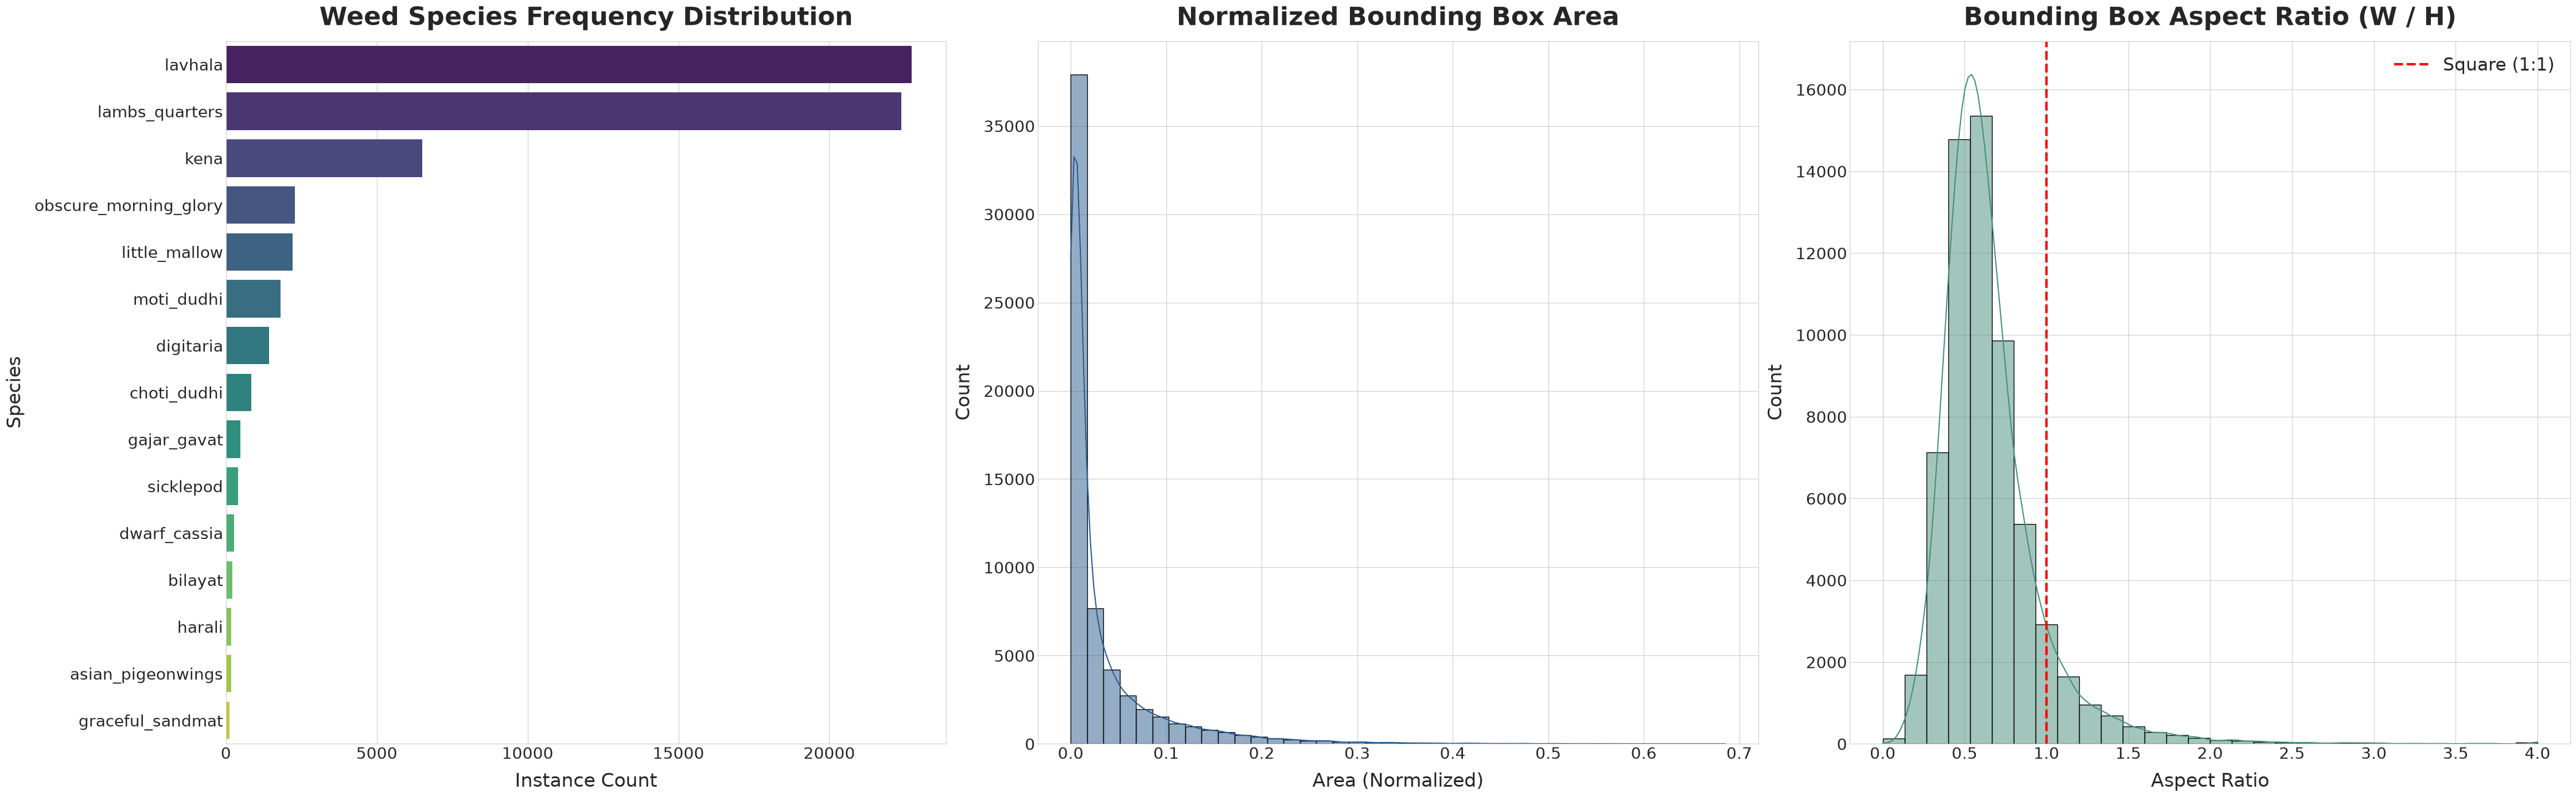

In [5]:
# Plot class distribution and bounding box geometry side-by-side
fig, axes = plt.subplots(1, 3, figsize=(45, 14))

# 1. Class distribution
species_counts = df_boxes['species'].value_counts()
sns.barplot(
    x=species_counts.values, 
    y=species_counts.index, 
    hue=species_counts.index, 
    legend=False, 
    ax=axes[0], 
    palette='viridis'
)
axes[0].set_title("Weed Species Frequency Distribution", fontsize=32, fontweight='bold', pad=20)
axes[0].set_xlabel("Instance Count", fontsize=24, labelpad=12)
axes[0].set_ylabel("Species", fontsize=24, labelpad=12)
axes[0].tick_params(axis='both', which='major', labelsize=20)

# 2. Bounding box area distribution
sns.histplot(df_boxes['area'], bins=40, kde=True, ax=axes[1], color='#2b5c8f')
axes[1].set_title("Normalized Bounding Box Area", fontsize=32, fontweight='bold', pad=20)
axes[1].set_xlabel("Area (Normalized)", fontsize=24, labelpad=12)
axes[1].set_ylabel("Count", fontsize=24, labelpad=12)
axes[1].tick_params(axis='both', which='major', labelsize=20)

# 3. Aspect ratio distribution
sns.histplot(df_boxes['aspect_ratio'].clip(0, 4), kde=True, ax=axes[2], color='#488f7b', bins=30)
axes[2].axvline(1.0, color='red', linestyle='--', linewidth=3.0, label='Square (1:1)')
axes[2].set_title("Bounding Box Aspect Ratio (W / H)", fontsize=32, fontweight='bold', pad=20)
axes[2].set_xlabel("Aspect Ratio", fontsize=24, labelpad=12)
axes[2].set_ylabel("Count", fontsize=24, labelpad=12)
axes[2].tick_params(axis='both', which='major', labelsize=20)
axes[2].legend(fontsize=22, loc='upper right')

plt.tight_layout()
plt.show()

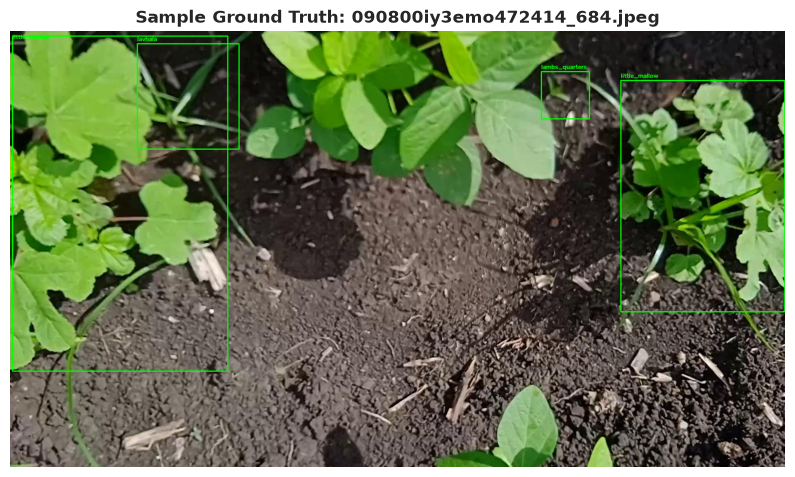

In [6]:
def show_sample_ground_truth(img_path, ann_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return
    h_img, w_img = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    if ann_path.exists():
        with open(ann_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x1 = int((xc - bw / 2.0) * w_img)
                y1 = int((yc - bh / 2.0) * h_img)
                x2 = int((xc + bw / 2.0) * w_img)
                y2 = int((yc + bh / 2.0) * h_img)
                species = CLASS_NAMES.get(cls_id, str(cls_id))
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img_rgb, species, (x1, max(20, y1 - 6)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title(f"Sample Ground Truth: {img_path.name}", fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

sample_img = raw_image_files[0]
sample_ann = LABELS_DIR / f"{sample_img.stem}.txt"
show_sample_ground_truth(sample_img, sample_ann)

## 4. Multi-Modal Feature Engineering and Spectral Vegetation Indices
Extract morphological dimensions, RGB/HSV color statistics, and agronomic vegetation indices across weed instances:
- Excess Green Index ($ExG = 2G - R - B$)
- Excess Red Index ($ExR = 1.4R - G$)
- Normalized Difference Index ($NDI = (G - R) / (G + R)$)
- Texture contrast via Laplacian variance

Extracting multi-modal features across all 6,656 raw frames...


Processing Images:   0%|          | 0/6656 [00:00<?, ?it/s]


Extraction complete in 149.21s: Extracted 62,040 weed instances.


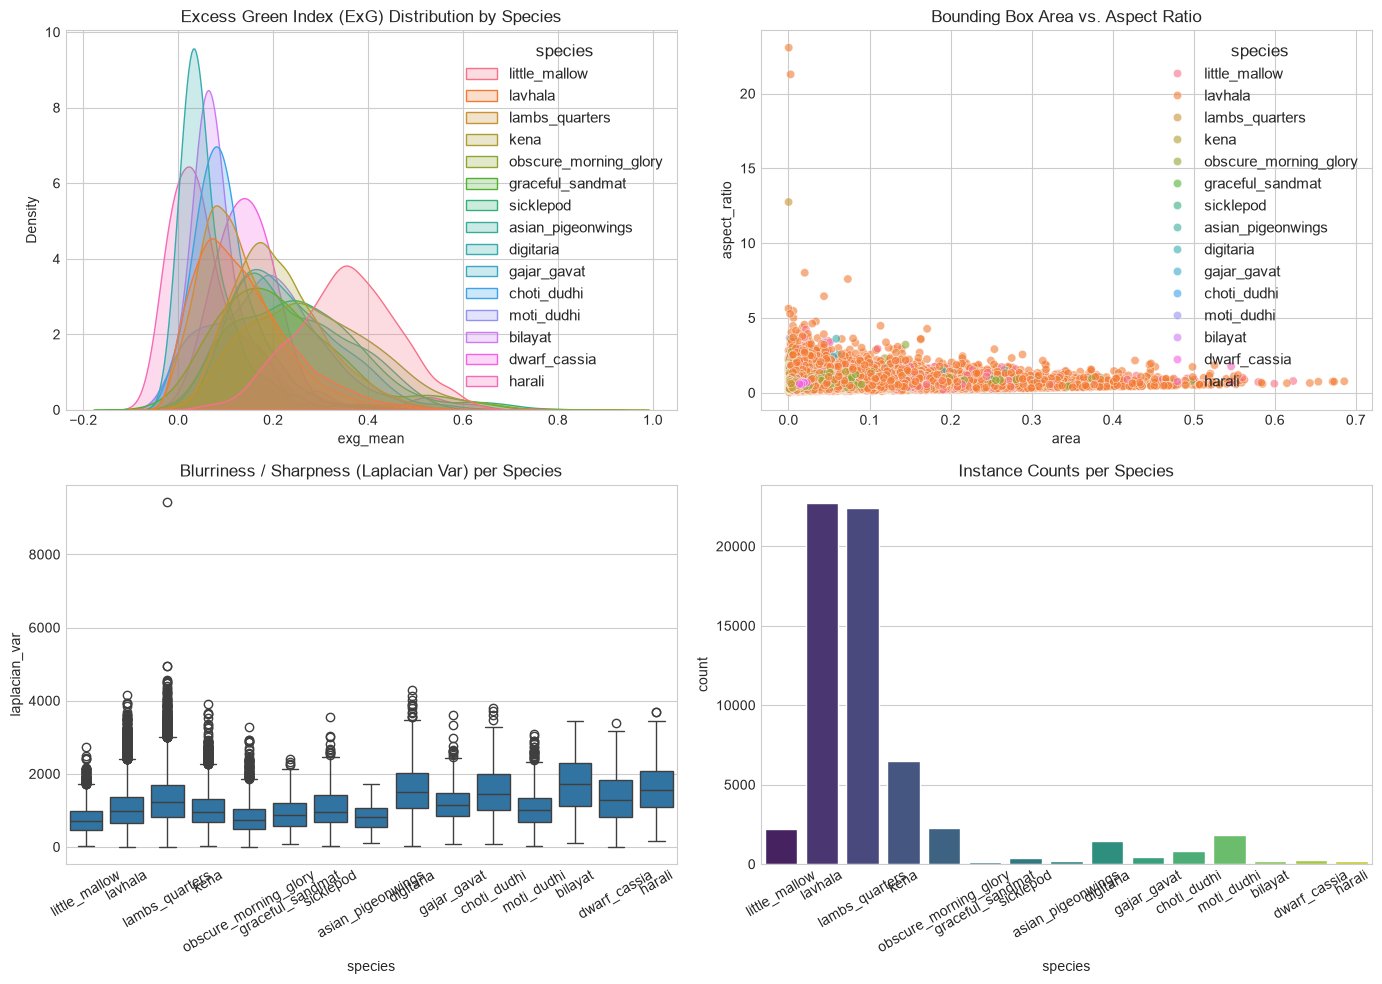

,image_name,class_id,species,xc,yc,width,height,aspect_ratio,area,perimeter,...,g_mean,b_mean,hue_mean,sat_mean,val_mean,exg_mean,exr_mean,ndi_mean,contrast_std,laplacian_var
0,090800iy3emo472414_684.jpeg,3,little_mallow,0.893750,0.378704,0.211458,0.531481,0.397866,0.112386,1.485880,...,0.415917,0.230628,41.825514,127.665042,107.498169,0.287341,0.023494,0.176177,60.557920,147.139817
1,090800iy3emo472414_684.jpeg,3,little_mallow,0.142187,0.395370,0.277083,0.768519,0.360542,0.212944,2.091204,...,0.496012,0.249384,36.404241,126.021992,128.776130,0.350125,0.053507,0.119047,53.225372,65.762377
2,090800iy3emo472414_684.jpeg,1,lavhala,0.229687,0.150000,0.131250,0.242593,0.541031,0.031840,0.747685,...,0.246645,0.144571,37.870355,104.473393,63.753391,0.149011,0.032946,0.096716,48.249966,46.202649
3,090800iy3emo472414_684.jpeg,2,lambs_quarters,0.716406,0.146759,0.061979,0.108333,0.572115,0.006714,0.340625,...,0.286917,0.222887,27.645120,72.371472,76.179272,0.071275,0.104624,0.006381,40.485350,77.894911
4,090805j6869f452411_137.jpeg,2,lambs_quarters,0.150781,0.609259,0.073438,0.107407,0.683728,0.007888,0.361690,...,0.381852,0.279632,38.699743,70.667706,102.747738,0.114123,0.136078,-0.004547,37.766097,82.787602


In [12]:
from tqdm.auto import tqdm


def extract_instance_features(img_path):
    # Pull instance features and bounding box crops for a single image
    ann_path = LABELS_DIR / f"{img_path.stem}.txt"
    if not ann_path.exists():
        return []

    img = cv2.imread(str(img_path))
    if img is None:
        return []

    h_img, w_img = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    with open(ann_path, "r", encoding="utf-8") as f:
        lines = [line.strip().split() for line in f if line.strip()]

    records = []
    for parts in lines:
        cls_id = int(parts[0])
        xc, yc, bw, bh = map(float, parts[1:5])

        x1 = max(0, int((xc - bw / 2.0) * w_img))
        y1 = max(0, int((yc - bh / 2.0) * h_img))
        x2 = min(w_img, int((xc + bw / 2.0) * w_img))
        y2 = min(h_img, int((yc + bh / 2.0) * h_img))

        patch_rgb = img_rgb[y1:y2, x1:x2]
        if patch_rgb.size < 12:
            continue

        patch_hsv = img_hsv[y1:y2, x1:x2]
        patch_gray = img_gray[y1:y2, x1:x2]

        rf = patch_rgb[:, :, 0].astype(np.float32) / 255.0
        gf = patch_rgb[:, :, 1].astype(np.float32) / 255.0
        bf = patch_rgb[:, :, 2].astype(np.float32) / 255.0

        exg = 2.0 * gf - rf - bf
        exr = 1.4 * rf - gf
        denom = gf + rf + 1e-6
        ndi = (gf - rf) / denom

        lap_var = (
            float(cv2.Laplacian(patch_gray, cv2.CV_64F).var())
            if patch_gray.size >= 16
            else 0.0
        )

        records.append({
            "image_name": img_path.name,
            "class_id": cls_id,
            "species": CLASS_NAMES.get(cls_id, str(cls_id)),
            "xc": xc,
            "yc": yc,
            "width": bw,
            "height": bh,
            "aspect_ratio": bw / max(bh, 1e-6),
            "area": bw * bh,
            "perimeter": 2.0 * (bw + bh),
            "center_dist": np.sqrt((xc - 0.5) ** 2 + (yc - 0.5) ** 2),
            "boxes_in_frame": len(lines),
            "r_mean": float(np.mean(rf)),
            "g_mean": float(np.mean(gf)),
            "b_mean": float(np.mean(bf)),
            "hue_mean": float(np.mean(patch_hsv[:, :, 0])),
            "sat_mean": float(np.mean(patch_hsv[:, :, 1])),
            "val_mean": float(np.mean(patch_hsv[:, :, 2])),
            "exg_mean": float(np.mean(exg)),
            "exr_mean": float(np.mean(exr)),
            "ndi_mean": float(np.mean(ndi)),
            "contrast_std": float(np.std(patch_gray)),
            "laplacian_var": lap_var,
        })

    return records


# Execution block
sample_feature_images = raw_image_files
total_images = len(sample_feature_images)

print(
    f"Extracting multi-modal features across all {total_images:,} raw frames..."
)
t0 = time.time()

extracted_batches = []
total_instances = 0

# Parallel feature processing with dynamic progress updates
with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
    # Pass map directly to tqdm to avoid iteration issues
    mapped_results = executor.map(
        extract_instance_features, sample_feature_images
    )
    pbar = tqdm(mapped_results, total=total_images, desc="Processing Images")

    for batch in pbar:
        extracted_batches.append(batch)
        total_instances += len(batch)
        # Update the right side of the status bar with the live weed count
        pbar.set_postfix({"Instances Extracted": f"{total_instances:,}"})

# Flatten list of lists into a clean DataFrame
feature_list = [r for batch in extracted_batches for r in batch]
df_features = pd.DataFrame(feature_list)
t1 = time.time()

print(
    f"\nExtraction complete in {t1 - t0:.2f}s: Extracted {len(df_features):,} weed instances."
)

# Plot visuals if features were extracted
if not df_features.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.set_theme(style="whitegrid")

    # 1. Excess Green (ExG) distribution by Species
    sns.kdeplot(
        data=df_features,
        x="exg_mean",
        hue="species",
        common_norm=False,
        fill=True,
        ax=axes[0, 0],
    )
    axes[0, 0].set_title("Excess Green Index (ExG) Distribution by Species")

    # 2. Aspect Ratio vs. Area Scatter Plot
    sns.scatterplot(
        data=df_features,
        x="area",
        y="aspect_ratio",
        hue="species",
        alpha=0.6,
        ax=axes[0, 1],
    )
    axes[0, 1].set_title("Bounding Box Area vs. Aspect Ratio")

    # 3. Image Sharpness (Laplacian Variance) Boxplot
    sns.boxplot(data=df_features, x="species", y="laplacian_var", ax=axes[1, 0])
    axes[1, 0].set_title("Blurriness / Sharpness (Laplacian Var) per Species")
    axes[1, 0].tick_params(axis="x", rotation=30)

    # 4. Instance count per species
    sns.countplot(
        data=df_features,
        x="species",
        hue="species",
        palette="viridis",
        legend=False,
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("Instance Counts per Species")
    axes[1, 1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

df_features.head()

In [19]:
# Quick sanity check on plot insights: toss blurry shots and weird box crops
BLUR_THRESHOLD = 300
MAX_ASPECT_RATIO = 6.0

df_clean = df_features[
    (df_features['laplacian_var'] >= BLUR_THRESHOLD) &
    (df_features['aspect_ratio'] <= MAX_ASPECT_RATIO)
].copy()

# Ensure no single-instance species remain to avoid downstream evaluation issues
class_counts = df_clean['species'].value_counts()
valid_species = class_counts[class_counts >= 2].index
df_clean = df_clean[df_clean['species'].isin(valid_species)].copy()

print(f"Dropped {len(df_features) - len(df_clean):,} junk rows (blurry, bad bounding boxes, or singletons).")

# Feature tweak: give model a boost on skinny grass (lavhala) & super green leaves (harali)
df_clean['area_to_aspect_ratio'] = df_clean['area'] / (df_clean['aspect_ratio'] + 1e-6)
df_clean['is_high_exg'] = (df_clean['exg_mean'] > 0.3).astype(int)

# Balance out class weights so minority weeds like dwarf_cassia don't get ignored
species_labels = df_clean['species'].values
unique_classes = np.unique(species_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=species_labels
)

class_weight_dict = dict(zip(unique_classes, class_weights))

print("\nClass weights ready for loss function:")
for species, weight in class_weight_dict.items():
    print(f"  {species}: {weight:.2f}")

# Extract image stems to align instance-level features directly with parent image splits
df_clean['image_stem'] = df_clean['image_name'].apply(lambda x: pathlib.Path(x).stem)

with open(ROOT_DIR / "train.txt", "r", encoding="utf-8") as f:
    train_stems = {pathlib.Path(line.strip()).stem for line in f if line.strip()}

with open(ROOT_DIR / "val.txt", "r", encoding="utf-8") as f:
    val_stems = {pathlib.Path(line.strip()).stem for line in f if line.strip()}

# Filter rows by parent image split to prevent data leakage across frames
train_mask = df_clean['image_stem'].isin(train_stems)
val_mask = df_clean['image_stem'].isin(val_stems)

drop_cols = [col for col in ['species', 'image_name', 'image_stem'] if col in df_clean.columns]

X_train = df_clean[train_mask].drop(columns=drop_cols)
y_train = df_clean[train_mask]['species']

X_val = df_clean[val_mask].drop(columns=drop_cols)
y_val = df_clean[val_mask]['species']

print(f"\nSplit done! Train: {len(X_train):,} instances | Val: {len(X_val):,} instances")

Dropped 3,030 junk rows (blurry, bad bounding boxes, or singletons).

Class weights ready for loss function:
  asian_pigeonwings: 24.28
  bilayat: 18.73
  choti_dudhi: 4.79
  digitaria: 2.86
  dwarf_cassia: 15.86
  gajar_gavat: 8.44
  graceful_sandmat: 34.51
  harali: 22.23
  kena: 0.63
  lambs_quarters: 0.18
  lavhala: 0.18
  little_mallow: 1.94
  moti_dudhi: 2.28
  obscure_morning_glory: 1.91
  sicklepod: 10.22

Split done! Train: 47,055 instances | Val: 5,964 instances


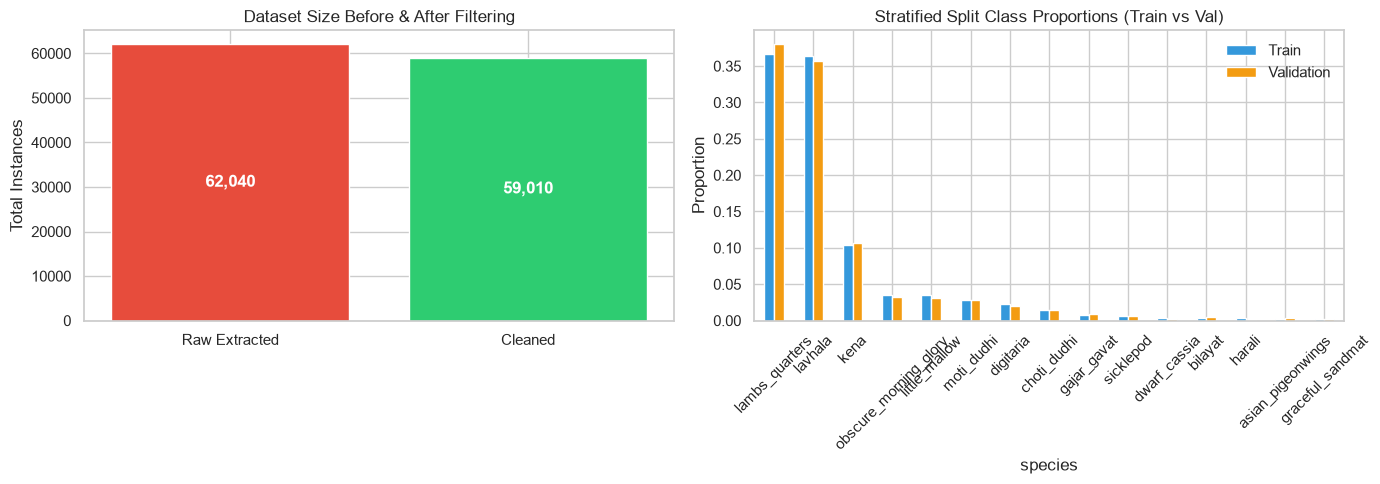

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Before vs. After data cleanup
axes[0].bar(['Raw Extracted', 'Cleaned'], [len(df_features), len(df_clean)], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Dataset Size Before & After Filtering')
axes[0].set_ylabel('Total Instances')
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height()):,}', 
                     (bar.get_x() + bar.get_width() / 2., bar.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

# 2. Train vs. Validation Split Proportion Verification
train_counts = y_train.value_counts(normalize=True).rename('Train')
val_counts = y_val.value_counts(normalize=True).rename('Validation')
split_df = pd.concat([train_counts, val_counts], axis=1)

split_df.plot(kind='bar', ax=axes[1], color=['#3498db', '#f39c12'])
axes[1].set_title('Stratified Split Class Proportions (Train vs Val)')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

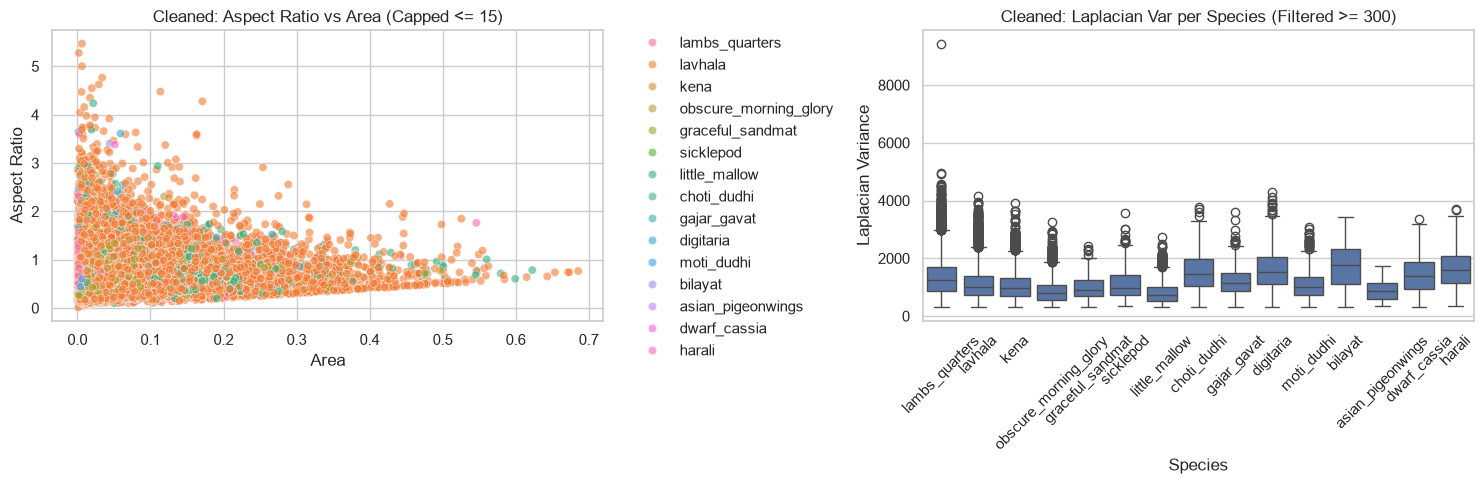

In [21]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Cleaned Aspect Ratio vs Area Scatter Plot
sns.scatterplot(
    data=df_clean, 
    x='area', 
    y='aspect_ratio', 
    hue='species', 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_title('Cleaned: Aspect Ratio vs Area (Capped <= 15)')
axes[0].set_xlabel('Area')
axes[0].set_ylabel('Aspect Ratio')

# Move legend outside so it doesn't block data points
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# 2. Cleaned Blurriness / Sharpness Boxplot
sns.boxplot(
    data=df_clean, 
    x='species', 
    y='laplacian_var', 
    ax=axes[1]
)
axes[1].set_title('Cleaned: Laplacian Var per Species (Filtered >= 300)')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Laplacian Variance')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Principal Component Analysis (PCA) and Dimensionality Reduction
Standardize the multi-modal feature matrix and project high-dimensional descriptors into 2D latent space to assess weed class separability.

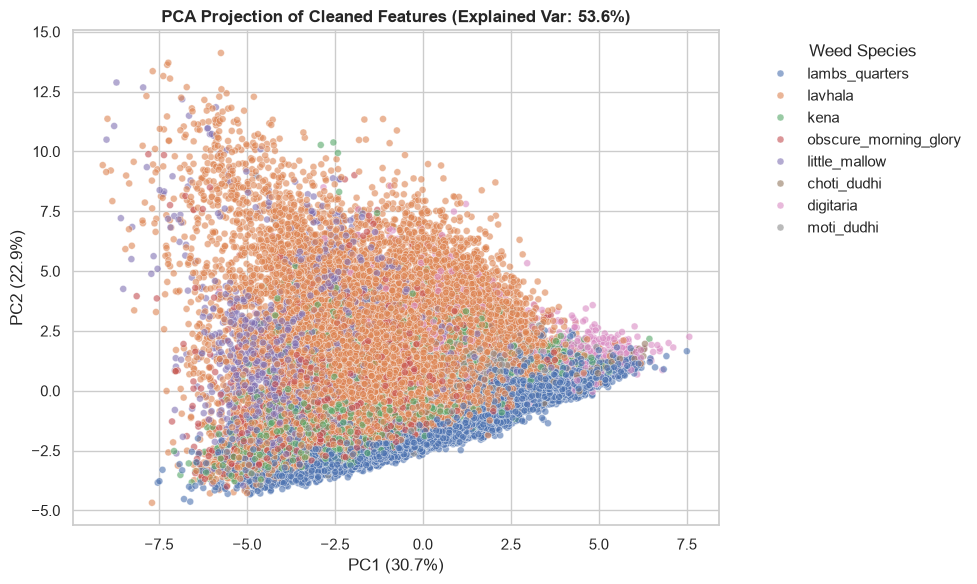

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Include the newly engineered features alongside original physical & color features
feature_cols = [
    'width', 'height', 'aspect_ratio', 'area', 'perimeter', 'center_dist',
    'r_mean', 'g_mean', 'b_mean', 'hue_mean', 'sat_mean', 'val_mean',
    'exg_mean', 'exr_mean', 'ndi_mean', 'contrast_std', 'laplacian_var',
    'area_to_aspect_ratio', 'is_high_exg'
]

# Work on df_clean to ensure bad crops/blurry images aren't skewing PCA
X = df_clean[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

# Assign PCA components directly back to df_clean
df_clean['pca_1'] = X_pca[:, 0]
df_clean['pca_2'] = X_pca[:, 1]

# Plot top species in PCA space
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

top_species = df_clean['species'].value_counts().head(8).index
sns.scatterplot(
    data=df_clean[df_clean['species'].isin(top_species)],
    x='pca_1',
    y='pca_2',
    hue='species',
    alpha=0.6,
    s=25
)

plt.title(f"PCA Projection of Cleaned Features (Explained Var: {pca.explained_variance_ratio_.sum()*100:.1f}%)", fontsize=12, fontweight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title="Weed Species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [23]:
# Create DataFrame of PCA loadings
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=feature_cols
)

print("Top Drivers for PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print("\nTop Drivers for PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

Top Drivers for PC1:
exr_mean    0.375172
b_mean      0.355548
r_mean      0.330188
sat_mean    0.319349
val_mean    0.254812
Name: PC1, dtype: float64

Top Drivers for PC2:
perimeter               0.414779
area                    0.414007
height                  0.400957
area_to_aspect_ratio    0.388938
width                   0.378868
Name: PC2, dtype: float64


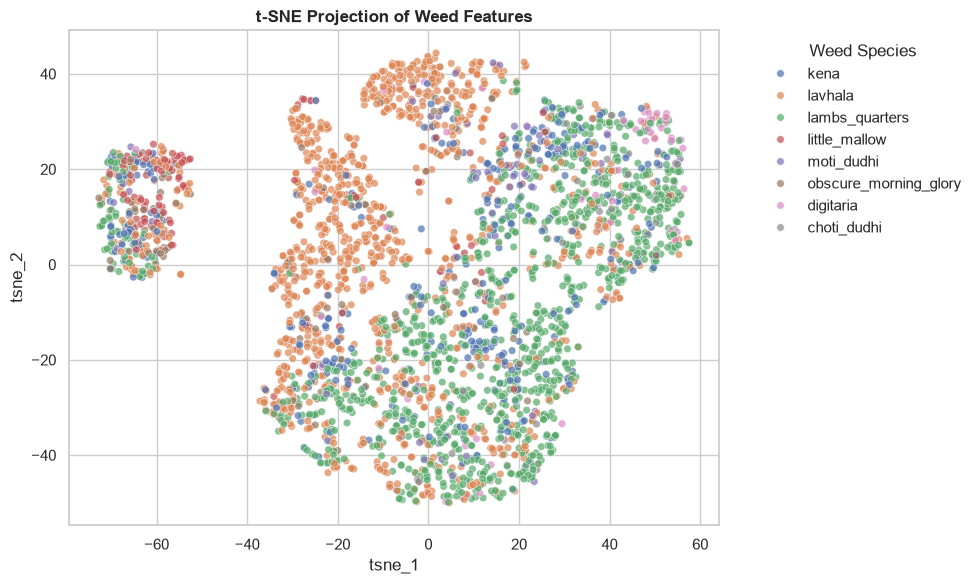

In [24]:
# Subsample for speed if dataset is huge
df_sample = df_clean[df_clean['species'].isin(top_species)].sample(n=3000, random_state=42)
X_sub = scaler.transform(df_sample[feature_cols].fillna(0))

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sub)

df_sample['tsne_1'] = X_tsne[:, 0]
df_sample['tsne_2'] = X_tsne[:, 1]

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.scatterplot(
    data=df_sample,
    x='tsne_1',
    y='tsne_2',
    hue='species',
    alpha=0.7,
    s=30
)
plt.title("t-SNE Projection of Weed Features", fontsize=12, fontweight='bold')
plt.legend(title="Weed Species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Outlier Detection and Anomaly Auditing
Utilize an Isolation Forest to identify anomalous or corrupt bounding box annotations (extreme aspect ratios, speckle noise, mislabeled large boxes).

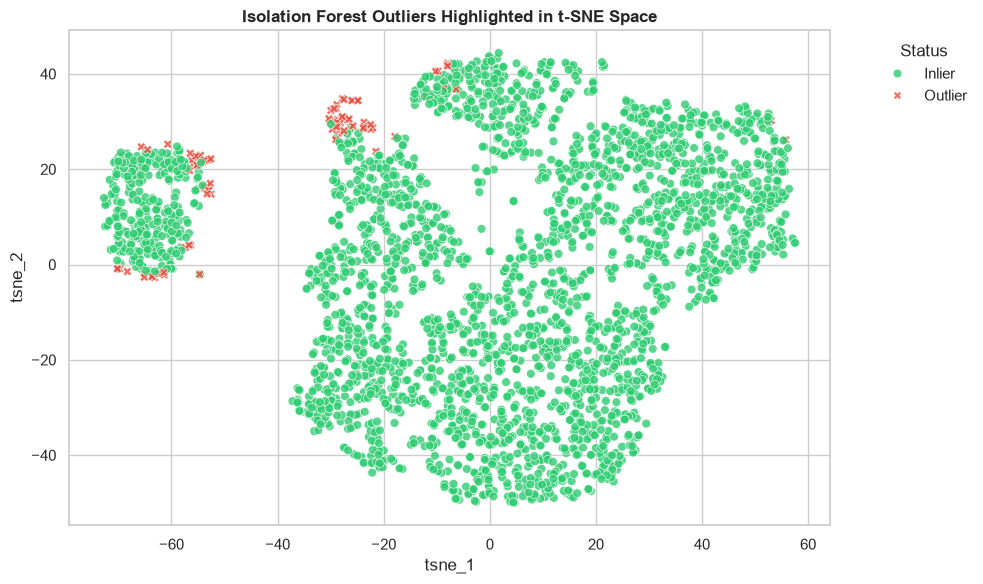

In [28]:
# 1. Prepare scaled feature DataFrames with column names
X_clean_scaled = pd.DataFrame(
    scaler.transform(df_clean[feature_cols].fillna(0)),
    columns=feature_cols
)

X_sample_scaled = pd.DataFrame(
    scaler.transform(df_sample[feature_cols].fillna(0)),
    columns=feature_cols
)

# 2. Fit IsolationForest on scaled data (contamination = 3% outliers)
iso_forest = IsolationForest(
    contamination=0.03, 
    random_state=42, 
    n_jobs=-1
)
iso_forest.fit(X_clean_scaled)

# 3. Predict on sample
df_sample['is_outlier'] = iso_forest.predict(X_sample_scaled)
df_sample['anomaly_status'] = df_sample['is_outlier'].map({1: 'Inlier', -1: 'Outlier'})

# 4. Plot again
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_sample,
    x='tsne_1',
    y='tsne_2',
    hue='anomaly_status',
    palette={'Inlier': '#2ecc71', 'Outlier': '#e74c3c'},
    style='anomaly_status',
    markers={'Inlier': 'o', 'Outlier': 'X'},
    alpha=0.8,
    s=40
)

plt.title("Isolation Forest Outliers Highlighted in t-SNE Space", fontsize=12, fontweight='bold')
plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [32]:
# 1. Ensure SEED is defined
SEED = 42

# 2. Extract features and scale
X_all_scaled = pd.DataFrame(
    scaler.transform(df_clean[feature_cols].fillna(0)),
    columns=feature_cols
)

# 3. Create df_final by filtering out outliers
df_clean['is_outlier'] = iso_forest.predict(X_all_scaled)
df_final = df_clean[df_clean['is_outlier'] == 1].copy()

print(f"df_final defined successfully with {len(df_final):,} clean rows.")

df_final defined successfully with 57,239 clean rows.


## 7. Bounding Box Anchor Geometry Analysis (K-Means)
Cluster normalized bounding box dimensions using K-Means to identify dominant spatial aspect ratios and scales in the MH-Weed16 dataset.

Custom Anchor Box Coordinates (Width, Height):
  Anchor 1: (0.0413, 0.0684)
  Anchor 2: (0.0887, 0.1434)
  Anchor 3: (0.1580, 0.2371)
  Anchor 4: (0.1778, 0.3801)
  Anchor 5: (0.3538, 0.3489)
  Anchor 6: (0.2797, 0.5692)


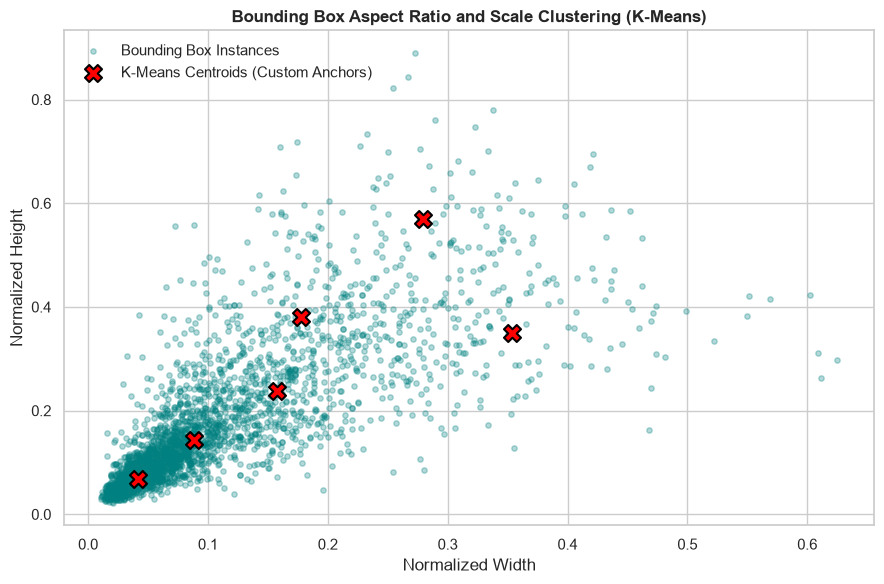

In [33]:
# 1. Use clean dataset and extract width/height
wh_data = df_final[['width', 'height']].values

k_clusters = 6
kmeans = KMeans(n_clusters=k_clusters, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(wh_data)
centroids = kmeans.cluster_centers_

# Sort centroids by area (width * height) for neat organization
centroids = centroids[np.argsort(centroids[:, 0] * centroids[:, 1])]

# 2. Print formatted anchor box sizes for object detection config
print("Custom Anchor Box Coordinates (Width, Height):")
for i, (w, h) in enumerate(centroids):
    print(f"  Anchor {i+1}: ({w:.4f}, {h:.4f})")

# 3. Plotting with fixed joint sampling
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Sample rows together to preserve (x, y) alignment
sample_df = df_final[['width', 'height']].sample(min(3000, len(df_final)), random_state=SEED)

plt.scatter(
    sample_df['width'],
    sample_df['height'],
    alpha=0.3,
    c='teal',
    s=15,
    label='Bounding Box Instances'
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    marker='X',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    label='K-Means Centroids (Custom Anchors)'
)

plt.title("Bounding Box Aspect Ratio and Scale Clustering (K-Means)", fontsize=12, fontweight='bold')
plt.xlabel("Normalized Width")
plt.ylabel("Normalized Height")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 8. Agricultural Image Contrast Enhancement (CLAHE and ExG)
Demonstrate field-level image enhancements for difficult lighting conditions using CLAHE (Contrast Limited Adaptive Histogram Equalization) and the Excess Green index.

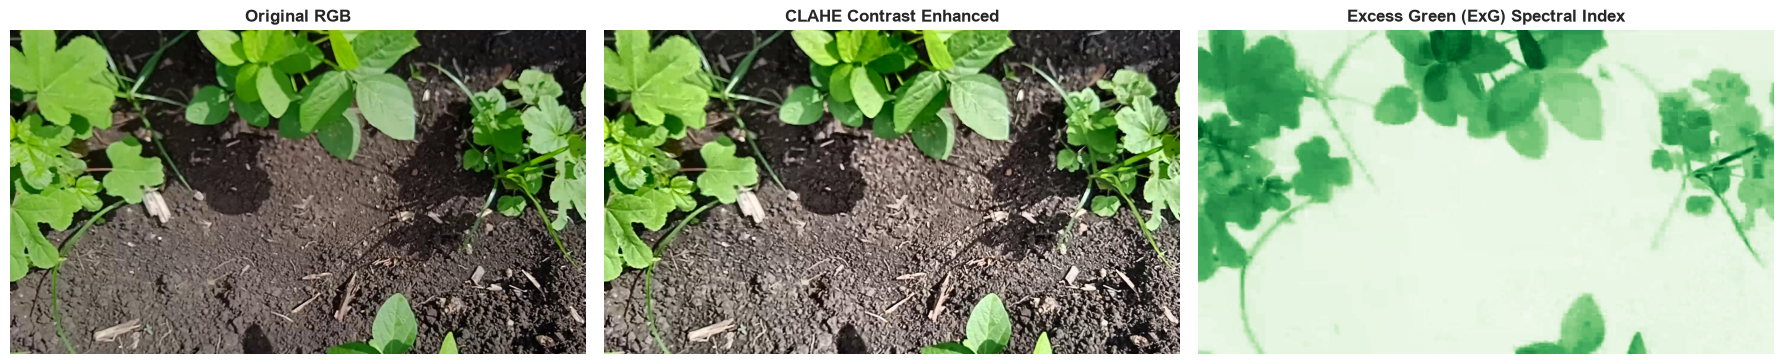

In [34]:
# Quick helper to boost contrast in the L channel without blowing out highlights
def apply_clahe(img_rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l_eq, a, b)), cv2.COLOR_LAB2RGB)

# Calculate Excess Green index (2G - R - B) to isolate green vegetation from soil/dirt
def compute_exg(img_rgb):
    rf = img_rgb[:, :, 0].astype(np.float32) / 255.0
    gf = img_rgb[:, :, 1].astype(np.float32) / 255.0
    bf = img_rgb[:, :, 2].astype(np.float32) / 255.0
    
    exg = 2.0 * gf - rf - bf
    
    # Scale from [-1, 1] back to standard uint8 image format [0, 255]
    return np.clip((exg + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)

# Grab a test image to inspect preprocessing
raw_path = str(raw_image_files[0])
sample_raw = cv2.imread(raw_path)

if sample_raw is None:
    raise FileNotFoundError(f"Failed to load sample image: {raw_path}")

sample_rgb = cv2.cvtColor(sample_raw, cv2.COLOR_BGR2RGB)
sample_clahe = apply_clahe(sample_rgb)
sample_exg = compute_exg(sample_rgb)

# Plot side-by-side to visually check image quality & green mask
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(sample_rgb)
axes[0].set_title("Original RGB", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(sample_clahe)
axes[1].set_title("CLAHE Contrast Enhanced", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(sample_exg, cmap='Greens')
axes[2].set_title("Excess Green (ExG) Spectral Index", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [35]:
from pathlib import Path
from ultralytics import YOLO

# Quick toggle and training config for the default baseline model
RUN_BASELINE = True
EPOCHS = 50
BATCH_SIZE = 8
IMG_SIZE = 640
BASELINE_RUN_NAME = "mhweed16_yolo11n_baseline"

# Set up run paths
baseline_run_dir = ROOT_DIR / "runs" / "detect" / BASELINE_RUN_NAME
baseline_last = baseline_run_dir / "weights" / "last.pt"

if RUN_BASELINE:
    print("=" * 65)
    print(f"Starting Baseline Training Run: {BASELINE_RUN_NAME}")
    print(f"Device: {device}")
    print("=" * 65)

    # Pick up where we left off if interrupted, otherwise grab stock yolo11n
    if baseline_last.exists():
        print(f"Found existing checkpoint! Resuming from: {baseline_last}")
        model_baseline = YOLO(str(baseline_last))
        baseline_args = {'resume': True}
    else:
        print("Spinning up fresh YOLO11n baseline (using default AdamW hyperparams)...")
        model_baseline = YOLO("yolo11n.pt")
        baseline_args = {
            'data': "mhweed16.yaml",
            'epochs': EPOCHS,
            'batch': BATCH_SIZE,
            'imgsz': IMG_SIZE,
            'device': device,
            'workers': 4,
            'name': BASELINE_RUN_NAME,
            'project': str(ROOT_DIR / "runs" / "detect"),
            'exist_ok': True,
            'pretrained': True,
            'optimizer': "AdamW",
            'patience': 15,
            'save': True
        }

    # Kick off baseline training
    baseline_results = model_baseline.train(**baseline_args)

    # Save initial scores so we can compare against our tuned run later
    baseline_map50 = baseline_results.results_dict.get('metrics/mAP50(B)', 0)
    baseline_map50_95 = baseline_results.results_dict.get('metrics/mAP50-95(B)', 0)

    print("\n" + "=" * 65)
    print("Baseline training complete!")
    print(f"  Baseline mAP50:    {baseline_map50:.4f}")
    print(f"  Baseline mAP50-95: {baseline_map50_95:.4f}")
    print("=" * 65)
else:
    print("RUN_BASELINE set to False — skipping baseline training.")

Starting Baseline Training Run: mhweed16_yolo11n_baseline
Device: xpu
Spinning up fresh YOLO11n baseline (using default AdamW hyperparams)...
New https://pypi.org/project/ultralytics/8.4.172 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.150  Python-3.14.7 torch-2.14.1+xpu XPU:0 (Intel(R) Arc(TM) Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=mhweed16.yaml, degrees=0.0, deterministic=True, device=xpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=

KeyboardInterrupt: 

## 9. Genetic Algorithm Hyperparameter Evolution (model.tune)
Ultralytics supports native Genetic Algorithm hyperparameter evolution.
By default, `RUN_TUNE = False` allows the notebook to run immediately using either previously saved optimal hyperparameters or robust defaults.

In [ ]:
RUN_TUNE = True         # Set to True to execute hyperparameter evolution
TUNE_ITERATIONS = 20     # Number of evolution generations
TUNE_EPOCHS = 30         # Epochs per trial
BATCH_SIZE = -1           # Batch size for compute device
IMG_SIZE = 640           # High-resolution input canvas

tune_results_file = ROOT_DIR / "tune_results.csv"
best_hyp_file = ROOT_DIR / "best_hyperparameters.yaml"

if RUN_TUNE:
    print("=" * 65)
    print("Starting Genetic Algorithm Hyperparameter Evolution via model.tune()...")
    tune_model = YOLO("yolo11n.pt")
    tune_model.tune(
        data="mhweed16.yaml",
        epochs=TUNE_EPOCHS,
        iterations=TUNE_ITERATIONS,
        optimizer="AdamW",
        plots=False,
        save=False,
        val=True,
        device=device,
        batch=BATCH_SIZE,
        imgsz=IMG_SIZE
    )
else:
    print("RUN_TUNE is set to False: Skipping hyperparameter evolution.")
    if best_hyp_file.exists():
        print(f"Discovered existing evolved hyperparameters: {best_hyp_file}")
    else:
        print("Using robust agricultural default hyperparameters for final training.")

Starting Genetic Algorithm Hyperparameter Evolution via model.tune()...
Tuner: Initialized Tuner instance with 'tune_dir=D:\proj\MHWeed16\mhweedaiml\runs\detect\tune-4'
Tuner:  Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/20 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'cls_pw': 0.0, 'dfl': 1.5, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0, 'close_mosaic': 10}

MultiTrainer 1/1: fine-tuning on mhweed16.yaml


## 10. Hyperparameter Visual Analytics Suite
Inspect evolution trials from `tune_results.csv` (if present) via fitness progression and hyperparameter correlations.

In [ ]:
if tune_results_file.exists():
    df_tune = pd.read_csv(tune_results_file)
    print(f"Loaded {len(df_tune)} completed evolution trial(s) from {tune_results_file.name}:")
    
    if 'generation' not in df_tune.columns:
        df_tune['generation'] = range(1, len(df_tune) + 1)
    
    fitness_col = 'fitness' if 'fitness' in df_tune.columns else ('metrics/mAP50-95(B)' if 'metrics/mAP50-95(B)' in df_tune.columns else None)
    
    if fitness_col:
        plt.figure(figsize=(10, 4))
        plt.plot(df_tune['generation'], df_tune[fitness_col], marker='o', color='#2b5c8f', linewidth=2)
        plt.title("Hyperparameter Evolution Fitness Progression", fontsize=12, fontweight='bold')
        plt.xlabel("Generation Trial")
        plt.ylabel("Fitness Score")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
else:
    print("Note: tune_results.csv not found. Execute Section 9 with RUN_TUNE = True to generate evolution analytics.")

## 11. Resumable Final Model Training and Evaluation
Train YOLO11 Nano (`yolo11n.pt`) with optimal hyperparameters.
The training block detects existing checkpoints and automatically resumes (`resume=True`) if `last.pt` is found.

In [ ]:
RUN_TRAIN = True
EPOCHS = 50
BATCH_SIZE = 8
IMG_SIZE = 640
RUN_NAME = "mhweed16_yolo11n_final"

run_dir = ROOT_DIR / "runs" / "detect" / RUN_NAME
weights_dir = run_dir / "weights"
last_weights = weights_dir / "last.pt"
best_weights = weights_dir / "best.pt"

if RUN_TRAIN:
    print("=" * 65)
    print(f"Final YOLO11n Training: {RUN_NAME}")
    print(f"Device:     {device} ({device_name})")
    print(f"Epochs:     {EPOCHS}")
    print(f"Batch:      {BATCH_SIZE}")
    print(f"Image Size: {IMG_SIZE}")
    print("=" * 65)
    
    if last_weights.exists():
        print(f"Resuming training from checkpoint: {last_weights}")
        model = YOLO(str(last_weights))
        train_args = {'resume': True}
    else:
        print("Initializing fresh YOLO11 Nano architecture (yolo11n.pt)...")
        model = YOLO("yolo11n.pt")
        train_args = {
            'data': "mhweed16.yaml",
            'epochs': EPOCHS,
            'batch': BATCH_SIZE,
            'imgsz': IMG_SIZE,
            'device': device,
            'workers': 4,
            'name': RUN_NAME,
            'project': "runs/detect",
            'exist_ok': True,
            'pretrained': True,
            'optimizer': "AdamW",
            'patience': 15,
            'save': True
        }
        if best_hyp_file.exists():
            with open(best_hyp_file, 'r', encoding='utf-8') as f:
                best_hyp = yaml.safe_load(f)
            train_args.update(best_hyp)
            print("Loaded evolved hyperparameters into training configuration.")
            
    results = model.train(**train_args)
else:
    print("RUN_TRAIN is set to False: Skipping model training.")

In [ ]:
# Evaluation on held-out test split
eval_weights = best_weights if best_weights.exists() else (last_weights if last_weights.exists() else pathlib.Path("yolo11n.pt"))
print(f"Evaluating checkpoint: {eval_weights}")

eval_model = YOLO(str(eval_weights))
metrics = eval_model.val(
    data="mhweed16.yaml",
    split="test",
    device=device,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE
)

print("=" * 60)
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print("=" * 60)

## 12. Inference, SAHI Sliced Prediction, and Edge Export
Demonstrate standard full-frame YOLO prediction against ground truth annotations, perform fine-grained Slicing Aided Hyper Inference (SAHI) on full 1080p images, and export the model to ONNX and OpenVINO.

In [ ]:
# Standard YOLO inference comparison
with open("test.txt", 'r', encoding='utf-8') as f:
    test_image_paths = [pathlib.Path(line.strip()) for line in f if line.strip()]

random.seed(123)
selected_test = random.sample(test_image_paths, min(3, len(test_image_paths)))

for test_path in selected_test:
    ann_path = LABELS_DIR / f"{test_path.stem}.txt"
    img = cv2.imread(str(test_path))
    gt_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img = gt_img.shape[:2]
    
    # Draw ground truth
    if ann_path.exists():
        with open(ann_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    xc, yc, bw, bh = map(float, parts[1:5])
                    x1 = int((xc - bw / 2.0) * w_img)
                    y1 = int((yc - bh / 2.0) * h_img)
                    x2 = int((xc + bw / 2.0) * w_img)
                    y2 = int((yc + bh / 2.0) * h_img)
                    cv2.rectangle(gt_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(gt_img, CLASS_NAMES.get(cls_id, str(cls_id)), (x1, max(20, y1 - 5)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    # Model prediction
    pred_res = eval_model.predict(source=str(test_path), imgsz=IMG_SIZE, conf=0.25, device=device, verbose=False)
    pred_img = pred_res[0].plot()[:, :, ::-1]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(gt_img)
    axes[0].set_title(f"Ground Truth: {test_path.name}", fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(pred_img)
    axes[1].set_title(f"YOLO11 Prediction: {test_path.name}", fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Slicing Aided Hyper Inference (SAHI)
sahi_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path=str(eval_weights),
    confidence_threshold=0.25,
    device=device if device != 'xpu' else 'cpu'
)

fig, axes = plt.subplots(len(selected_test), 2, figsize=(16, 6 * len(selected_test)))
if len(selected_test) == 1:
    axes = np.expand_dims(axes, axis=0)

for idx, test_p in enumerate(selected_test):
    raw = cv2.imread(str(test_p))
    gt_img = cv2.cvtColor(raw.copy(), cv2.COLOR_BGR2RGB)
    pred_img = cv2.cvtColor(raw.copy(), cv2.COLOR_BGR2RGB)
    h, w = gt_img.shape[:2]
    
    ann_p = LABELS_DIR / f"{test_p.stem}.txt"
    if ann_p.exists():
        with open(ann_p, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cid = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x1, y1 = int((xc - bw / 2) * w), int((yc - bh / 2) * h)
                x2, y2 = int((xc + bw / 2) * w), int((yc + bh / 2) * h)
                cv2.rectangle(gt_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(gt_img, CLASS_NAMES.get(cid, str(cid)), (x1, max(20, y1 - 5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    sahi_result = get_sliced_prediction(
        str(test_p),
        sahi_model,
        slice_height=640,
        slice_width=640,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
        verbose=0
    )
    
    for obj in sahi_result.object_prediction_list:
        bbox = obj.bbox.to_xyxy()
        x1, y1, x2, y2 = map(int, bbox)
        cat_name = obj.category.name
        score = obj.score.value
        cv2.rectangle(pred_img, (x1, y1), (x2, y2), (255, 50, 50), 2)
        cv2.putText(pred_img, f"{cat_name} {score:.2f}", (x1, max(20, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 50, 50), 2)

    axes[idx, 0].imshow(gt_img)
    axes[idx, 0].set_title(f"Ground Truth ({test_p.name})", fontsize=11, fontweight='bold')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(pred_img)
    axes[idx, 1].set_title(f"SAHI 640x640 Sliced Inference ({len(sahi_result.object_prediction_list)} weeds)", fontsize=11, fontweight='bold')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Export model for edge deployment
print("Exporting model for edge deployment...")

# Export to ONNX format
try:
    onnx_path = eval_model.export(format="onnx", dynamic=True)
    print(f"Successfully exported ONNX model: {onnx_path}")
except Exception as e:
    print(f"ONNX export skipped: {e}")